# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [2]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [3]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [4]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [5]:
def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column build a stable token like "site_id=site_id_42", hash it to
    an integer in [0, D), and collect those indices. Use a deterministic hash
    (hashlib), NOT Python's built-in hash() which is salted per process.
    """
    # TODO: hash each "col=value" token into [0, D) and return the index list.

    indices = []
    for col in cols:
        token = col + "=" + str(row[col])
        hex_digest = hashlib.md5(token.encode()).hexdigest()
        bucket = int(hex_digest, 16) % D
        indices.append(bucket)
    return indices


def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)

## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


z = w·x + b, p = sigmoid(z), ℓ = -(y log p + (1-y) log(1-p))

Chain rule: dℓ/dp = (p - y) / (p(1-p)), and dp/dz = p(1-p), so multiplying
them the p(1-p) cancels:

dℓ/dz = p - y

Since z is linear in w and b:

**dℓ/dw = (p - y) x**
**dℓ/db = p - y**

For the hashed version, x is all 0s except 1s at the 8 hashed buckets, so the
gradient is 0 for every other weight. The update only touches the active
buckets: w[j] -= lr * (p - y) for each active j, and b -= lr * (p - y).
Each step costs the same no matter how big D is.

## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [6]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    w = np.zeros(D)
    b = 0.0
    g = np.random.default_rng(seed)
    for _ in range(epochs):
        order = g.permutation(len(y))
        for i in order:
            idx = X_idx[i]
            z = b + w[idx].sum()
            p = sigmoid(z)
            grad = p - y[i]
            for j in idx:
                w[j] = w[j] - lr * (grad + l2 * w[j])
            b = b - lr * grad
    return w, b


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))

## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [7]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    order = np.argsort(-p)
    y_sorted = np.asarray(y)[order]
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    precision = tp / (tp + fp)
    recall = tp / y_sorted.sum()
    return recall, precision


def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    recall, precision = pr_curve(y, p)
    steps = np.diff(np.concatenate(([0.0], recall)))
    return float(np.sum(precision * steps))

baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4125
model avg precision (PR-AUC): 0.3424
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


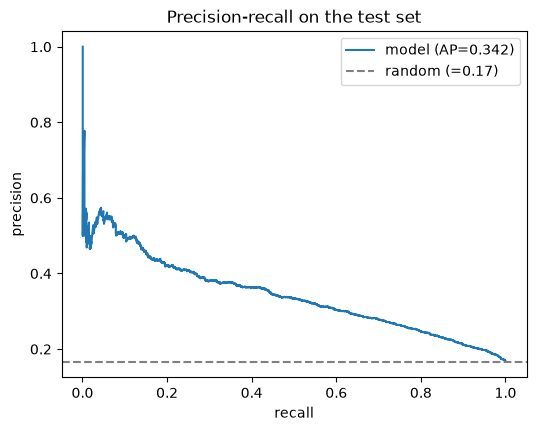

In [8]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [9]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    Xtr_k = build_index_matrix(train_df, CAT_COLS, Dk)
    Xte_k = build_index_matrix(test_df, CAT_COLS, Dk)
    w_k, b_k = train_logreg_sgd(Xtr_k, y_train, Dk, lr=0.1, epochs=3)
    p_k = predict_proba(Xte_k, w_k, b_k)
    ap_by_D.append(average_precision(y_test, p_k))
    ll_by_D.append(log_loss(y_test, p_k))

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")

D=2^ 8  AP=0.263  logloss=0.4449
D=2^10  AP=0.300  logloss=0.4331
D=2^12  AP=0.324  logloss=0.4225
D=2^14  AP=0.338  logloss=0.4155
D=2^16  AP=0.341  logloss=0.4135
D=2^18  AP=0.342  logloss=0.4125


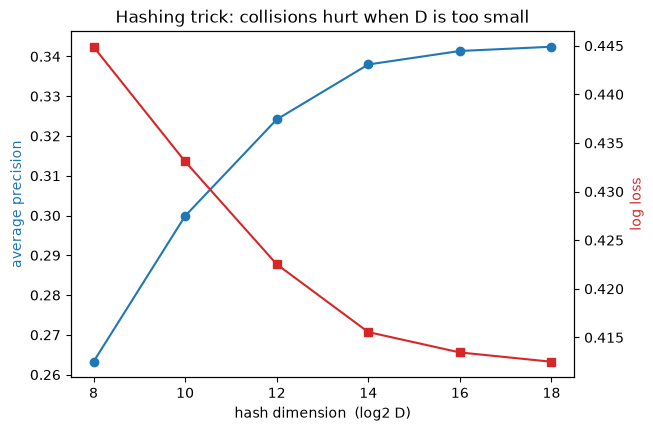

In [10]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [11]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    mean_predicted = []
    empirical_rate = []
    for k in range(n_bins):
        mask = bin_ids == k
        if mask.any():
            mean_predicted.append(p[mask].mean())
            empirical_rate.append(np.asarray(y)[mask].mean())
    return np.array(mean_predicted), np.array(empirical_rate)

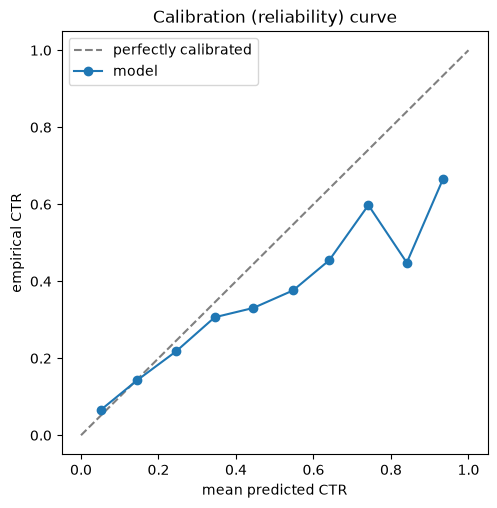

In [12]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


1. Always predicting no-click gets about 83% accuracy because 1-.17 while catching zero clicks, so accuracy looks good while being useless. Log-loss actually grades the probabilities and punishes confident wrong answers, and the PR curve would focus on the rare click class. I believe that random guessing only gets precision about 0.17 there, so any precision above 0.17 shows the model actually learned something.

2. We gain fixed memory, since the model is just D weights no matter how many IDs are out there is no need for a giant lookup table mapping every value to its own column. We also gain the ability to handle unseen values at test time, because a brand new device_id just hashes to some bucket like everything else instead of breaking. I would say we lost accuracy from collisions, since different values can end up in the same bucket and have to share a weight. Our D sweep starts to hurt around 2^12 and below. The average precision was pretty much flat from 2^18 down to 2^14 , then slipped at 2^12, then dropped at 2^10 , and then got really bad at 2^8. Im pretty sure that  happens because the data has around 9000 distinct tokens, so once D gets close to that number, collisions go from barely happening to constant and the model can't really tell different values apart anymore.

3. The gradient we derived is dℓ/dw = (p − y)x for the weights and dℓ/db = p − y for the bias which basically the error times the input. Since x is all zeros except for 1s at the 8 hashed bucket positions, the gradient is zero for every other weight, so each gradient descent step only actually updates those 8 weights plus the bias that we got. Everything else in w just sits untouched. That's what makes this scale to billions of features because the cost of one update depends on how many features are active like the 8 here, not on how big D is.

4. My curve follows the diagonal in the low range where most predictions live, but above about 0.3 it dips below it, the model predicts higher click rates than actually happen so it's a bit overconfident at the high end. Bidding needs calibrated probabilities because the bid is basically predicted CTR × click value, the number itself gets used, not just the ranking.

5. I researched what would handle class imbalances most effectively and the one that I concluded was negative downsampling. During training, we keep every click but randomly throw out most of the no-clicks, so the two classes are more balanced. This can push the  curve up a little bit, because the model isn't drowning in no-click examples anymore and learns the clicks better. I think the biggest downside is calibration could get messed up since clicks looked way more common during training than they really are, the model's predicted probabilities would all come out too high, so the reliability curve ends up above the diagonal instead of on it.

## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
